In [5]:
import pandas as pd

In [9]:
df = pd.read_csv("sales_data_cleaned_final1.csv")

In [10]:
df.head()


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,03-02-2023,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,21-04-2023,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,21-09-2023,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,24-08-2023,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,24-03-2023,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [12]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   str    
 2   Sales_Rep             1000 non-null   str    
 3   Region                1000 non-null   str    
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   str    
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   str    
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   str    
 12  Sales_Channel         1000 non-null   str    
 13  Region_and_Sales_Rep  1000 non-null   str    
dtypes: float64(4), int64(2), str(8)
memory usage: 109.5 KB


In [14]:
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [16]:
df.duplicated.sum()

AttributeError: 'function' object has no attribute 'sum'

In [18]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.dtypes


Product_ID                int64
Sale_Date                   str
Sales_Rep                   str
Region                      str
Sales_Amount            float64
Quantity_Sold             int64
Product_Category            str
Unit_Cost               float64
Unit_Price              float64
Customer_Type               str
Discount                float64
Payment_Method              str
Sales_Channel               str
Region_and_Sales_Rep        str
dtype: object

In [22]:
df["Sale_Date"].head()

0    03-02-2023
1    21-04-2023
2    21-09-2023
3    24-08-2023
4    24-03-2023
Name: Sale_Date, dtype: str

In [24]:
df["Sale_Date"].dtype

<StringDtype(storage='python', na_value=nan)>

In [25]:
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"], format="%d-%m-%Y")


In [26]:
df["Sale_Date"].dtype

dtype('<M8[us]')

In [27]:
df.describe()


,Product_ID,Sale_Date,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,2023-07-02 17:42:43.200000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
min,1001.000000,2023-01-01 00:00:00,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2023-03-30 00:00:00,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,2023-06-30 12:00:00,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,2023-10-12 00:00:00,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,2024-01-01 00:00:00,9989.040000,49.000000,4995.300000,5442.150000,0.30000
std,29.573505,NaN,2846.790126,14.159006,1417.872546,1419.399839,0.08720


In [28]:
df.select_dtypes(include="object").nunique()

C:\Windows\Temp\ipykernel_4400\251659734.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").nunique()


Sales_Rep                5
Region                   4
Product_Category         4
Customer_Type            2
Payment_Method           3
Sales_Channel            2
Region_and_Sales_Rep    20
dtype: int64

In [30]:
for col in df.select_dtypes(include="object").columns:
    print("\n", col)
    print(df[col].unique())


 Sales_Rep
<StringArray>
['Bob', 'David', 'Charlie', 'Eve', 'Alice']
Length: 5, dtype: str

 Region
<StringArray>
['North', 'West', 'South', 'East']
Length: 4, dtype: str

 Product_Category
<StringArray>
['Furniture', 'Food', 'Clothing', 'Electronics']
Length: 4, dtype: str

 Customer_Type
<StringArray>
['Returning', 'New']
Length: 2, dtype: str

 Payment_Method
<StringArray>
['Cash', 'Bank Transfer', 'Credit Card']
Length: 3, dtype: str

 Sales_Channel
<StringArray>
['Online', 'Retail']
Length: 2, dtype: str

 Region_and_Sales_Rep
<StringArray>
[    'North-Bob',      'West-Bob',   'South-David',     'South-Bob',
  'East-Charlie',  'West-Charlie',     'South-Eve',     'North-Eve',
      'West-Eve',   'South-Alice', 'South-Charlie',   'North-David',
      'East-Bob',    'West-David',      'East-Eve',   'North-Alice',
    'East-David',    'West-Alice',    'East-Alice', 'North-Charlie']
Length: 20, dtype: str


C:\Windows\Temp\ipykernel_4400\3376868075.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [31]:
df["Sales_Channel"].unique()

<StringArray>
['Online', 'Retail']
Length: 2, dtype: str

In [32]:
df["Region_and_Sales_Rep"].unique()

<StringArray>
[    'North-Bob',      'West-Bob',   'South-David',     'South-Bob',
  'East-Charlie',  'West-Charlie',     'South-Eve',     'North-Eve',
      'West-Eve',   'South-Alice', 'South-Charlie',   'North-David',
      'East-Bob',    'West-David',      'East-Eve',   'North-Alice',
    'East-David',    'West-Alice',    'East-Alice', 'North-Charlie']
Length: 20, dtype: str

In [34]:
(df.select_dtypes(include="number") < 0).sum()

Product_ID       0
Sales_Amount     0
Quantity_Sold    0
Unit_Cost        0
Unit_Price       0
Discount         0
dtype: int64

In [37]:
df["Sales_Amount"].plot(kind="box")

ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.

In [38]:
%pip install matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/88/89/56649bbaa2fd12e20f3be03dbcc135b0c8676d88bac17977599e3eb442a0/matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     -------------------------------------- 80.3/80.3 kB 224.4 kB/s eta 0:00:00
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/19/e8/6026ed58a64563186a9ee3f29f41261fd1828f527dd93d33b60feca63352/contourpy-1.3.3-cp312-cp312

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: >

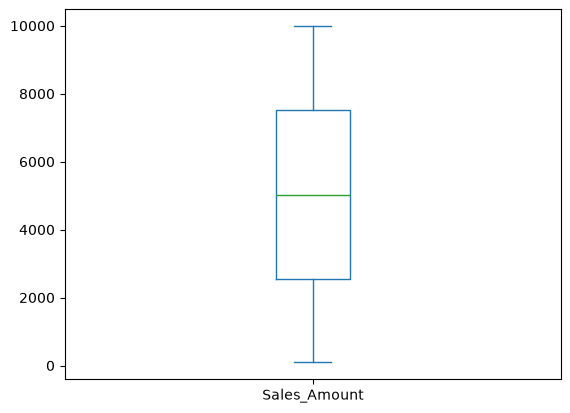

In [39]:
df["Sales_Amount"].plot(kind="box")

In [40]:
Q1 = df["Sales_Amount"].quantile(0.25)
Q3 = df["Sales_Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Sales_Amount"] < lower) | (df["Sales_Amount"] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 0


In [41]:
for col in ["Quantity_Sold", "Unit_Cost", "Unit_Price", "Discount"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, ":", len(outliers), "outliers")

Quantity_Sold : 0 outliers
Unit_Cost : 0 outliers
Unit_Price : 0 outliers
Discount : 0 outliers


In [42]:
print("Rows and columns:", df.shape)
print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Rows and columns: (1000, 14)

Missing values:
0

Duplicate rows: 0

Data types:
Product_ID                       int64
Sale_Date               datetime64[us]
Sales_Rep                          str
Region                             str
Sales_Amount                   float64
Quantity_Sold                    int64
Product_Category                   str
Unit_Cost                      float64
Unit_Price                     float64
Customer_Type                      str
Discount                       float64
Payment_Method                     str
Sales_Channel                      str
Region_and_Sales_Rep               str
dtype: object


In [43]:
df.to_csv("sales_data_cleaned_final.csv", index=False)

In [44]:
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [45]:
df.to_csv("sales_data_cleaned_final.csv", index=False)

In [46]:
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
